# **Taller Práctico: Análisis de Series de Tiempo Financieras como Procesos Estocásticos**

Maestría en Ingeniería Electrónica

Universidad de Nariño Curso

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera


En este cuaderno construiremos un marco empírico para analizar datos del mercado de valores, específicamente el índice S&P 500, tratándolo como un proceso estocástico en tiempo discreto $X[n]$.
De acuerdo con la teoría de procesos estocásticos, cada resultado de un experimento se mapea a una colección de variables aleatorias en el tiempo. Aquí, consideraremos que cada año (de 1970 a 2025) es una realización empírica independiente (o trayectoria) del proceso, y los días de cotización representan el índice de tiempo discreto $n$.
Para que todas las trayectorias partan del mismo estado inicial, normalizaremos cada año dividiendo todos sus valores por el valor de cierre del primer día del año, asegurando que $X[0]=1$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# **1. Adquisición y Preparación del Dataset (Data Wrangling)**
Extraeremos el histórico del índice S&P 500 (^GSPC) desde el primero de enero de 1970. Dado que un año financiero típico tiene aproximadamente 252 días de cotización, extraeremos los primeros 250 días de cada año para formar una matriz homogénea de dimensión $M \times N$, donde $M$ es el número de años (realizaciones) y $N=250$ el número de instantes de tiempo.

[*********************100%***********************]  1 of 1 completed


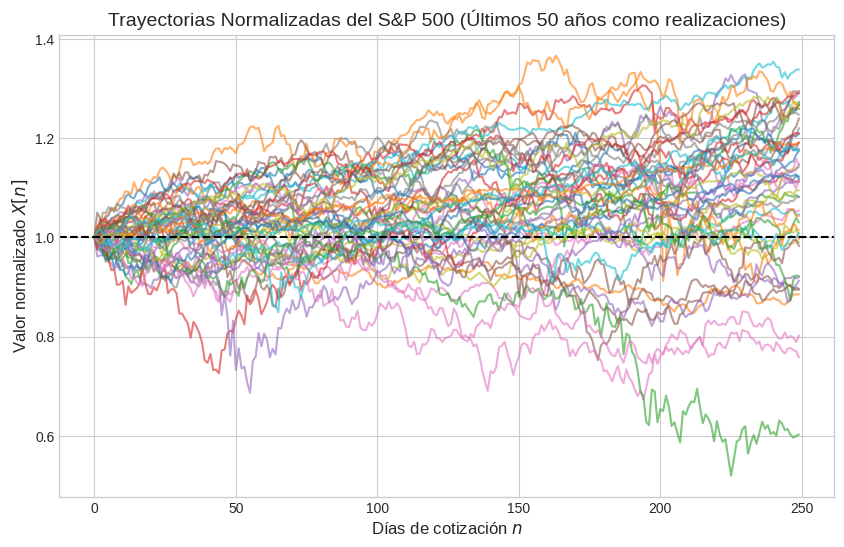

In [2]:
# 1. Descarga de datos
ticker = '^GSPC'
df_sp500 = yf.download(ticker, start='1970-01-01', end='2025-12-31')

# Usamos la columna 'Close' para el cierre diario
# Si yfinance devuelve un MultiIndex, lo aplanamos
if isinstance(df_sp500.columns, pd.MultiIndex):
    precios = df_sp500['Close'].squeeze()
else:
    precios = df_sp500['Close']

# 2. Agrupación por año y construcción del ensamble de trayectorias
years = range(1970, 2026)
N_dias = 250 # Fijamos 250 días de cotización por año para tener una matriz uniforme
M = len(years)

# Matriz que contendrá el proceso estocástico X_n
X = np.zeros((M, N_dias))

for i, year in enumerate(years):
    # Extraemos los precios del año correspondiente
    datos = precios[precios.index.year == year].values

    # Verificamos que haya suficientes datos
    if len(datos) > N_dias:
        # Se recordan los datos a N_dias
        X[i, :] = datos[:N_dias]

    elif len(datos) < N_dias: # Si tiene menos de 250 días, rellenamos con el último valor
        # np.pad agrega 0 datos al inicio y N_dias - len(datos) datos al final
        # La opción 'edge' rellena con el último valor encontrado en la serie
        X[i, :] = np.pad(datos, (0, N_dias - len(datos)), 'edge')

    else:
        X[i, :] = datos

    # Normalización: X[n] = Precio[n] / Precio[0]
    X[i, :] = X[i, :]/X[i, 0]

# Visualización de un subconjunto de trayectorias (ej. últimas 50 realizaciones)
plt.figure(figsize=(10, 6))
for i in range(max(0, M-50), M):
    plt.plot(range(N_dias), X[i, :], alpha=0.6, lw=1.5)

plt.title('Trayectorias Normalizadas del S&P 500 (Últimos 50 años como realizaciones)', fontsize=14)
plt.xlabel('Días de cotización $n$', fontsize=12)
plt.ylabel('Valor normalizado $X[n]$', fontsize=12)
plt.axhline(1.0, color='black', linestyle='--')
plt.show()

# **Reto 1: Caracterización de Primer Orden (Estimación de PDFs)**
Para un tiempo discreto fijo $n$, $X[n]$ representa una variable aleatoria caracterizada por su función de densidad de probabilidad $f_X​(x,n)$.
Tu tarea:
1. Seleccione los datos del ensamble (la matriz X) para los instantes de tiempo (días) n=1, n=100 y n=200.
2. Estime y grafique la PDF para cada uno de estos días en una misma figura con 3 subgráficos (puedes usar sns.histplot con la opción kde=True).
3. Análisis: Observe las tres gráficas. ¿Qué sucede con la dispersión (varianza) de los posibles valores del índice a medida que avanza el año? Argumenta tu respuesta en una celda de texto.

[*********************100%***********************]  1 of 1 completed


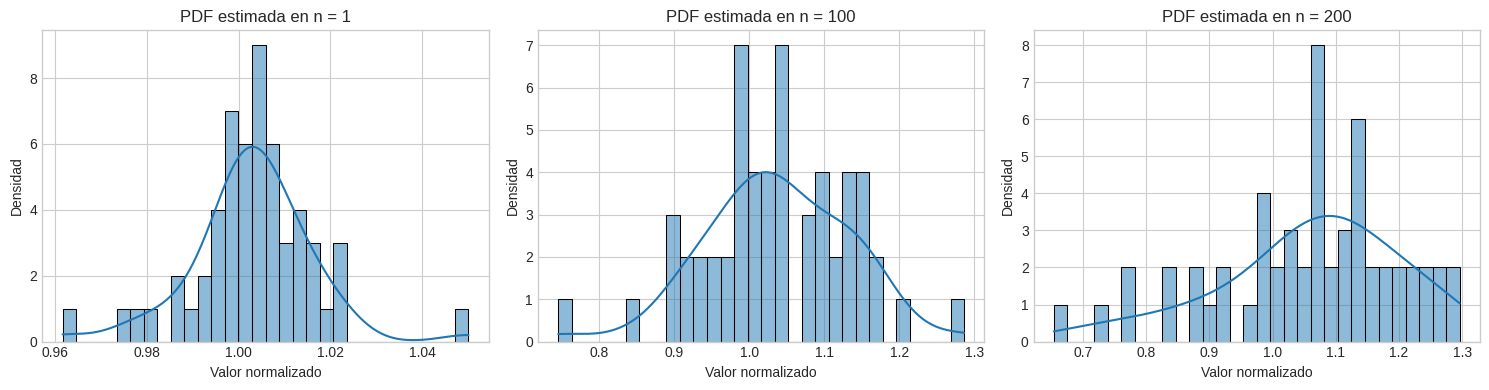

In [7]:
# Incluya aquí el código del Reto 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sp500 = yf.download("^GSPC", start="1970-01-01", end="2025-12-31")
sp500 = sp500[['Close']]
sp500.dropna(inplace=True)

sp500['Year'] = sp500.index.year

trayectorias = {}

for year, data in sp500.groupby('Year'):
    data = data.copy()
    data['Normalized'] = data['Close'] / data['Close'].iloc[0]
    data['n'] = np.arange(len(data))
    trayectorias[year] = data

df_all = pd.concat(trayectorias.values())

tiempos = [1, 100, 200]

plt.figure(figsize=(15, 4))

for i, t in enumerate(tiempos):
    plt.subplot(1, 3, i+1)

    valores = df_all[df_all['n'] == t]['Normalized']

    sns.histplot(valores, kde=True, bins=30)

    plt.title(f"PDF estimada en n = {t}")
    plt.xlabel("Valor normalizado")
    plt.ylabel("Densidad")

plt.tight_layout()
plt.show()


**Análisis**

A medida que aumenta el tiempo $n$, se observa que la distribución de los valores del índice se vuelve más dispersa. Para $n = 1$, los valores están muy concentrados alrededor de 1, ya que ha transcurrido poco tiempo desde la normalización inicial.

En $n = 100$ y $n = 200$, la distribución se ensancha progresivamente, lo que indica un aumento en la varianza del proceso.

Este comportamiento es consistente con procesos estocásticos como la caminata aleatoria, donde la incertidumbre se acumula a medida que avanza el tiempo. En consecuencia, a mayor valor de $n$, mayor es la variabilidad de los posibles valores del índice.

# **Reto 2: Valor Esperado y Varianza del Proceso Estocástico**
El primer momento probabilístico o valor esperado del proceso se define como $\mu[n]=E\{X[n]\}$. Su varianza se define como $\mathrm{var}\{X[n]\}=\mathbf{E}\{(X[n]−\mu[n])^2\}$. La tarea:

1. Calcule empíricamente el valor esperado $\mu[n]$ promediando a través del ensamble (las $M$ realizaciones) para cada uno de los $N$ días.
2. Calcule empíricamente la varianza transversal para cada uno de los $N$ días.
3. Grafique el valor esperado empírico $\mu[n]$ en función de $n$ (días de cotización). Añade una línea de referencia en el nivel base $X[0]=1$.
4. Grafique la varianza empírica en función de $n$ en otro panel.
5. Análisis: Un proceso es Estacionario en Sentido Amplio (WSS) si su valor esperado es constante en el tiempo y su función de autocorrelación depende únicamente de la diferencia de tiempo $\tau$. Basado en las gráficas, ¿el índice S&P 500 puede modelarse como un proceso estocástico WSS? ¿Por qué?

[*********************100%***********************]  1 of 1 completed


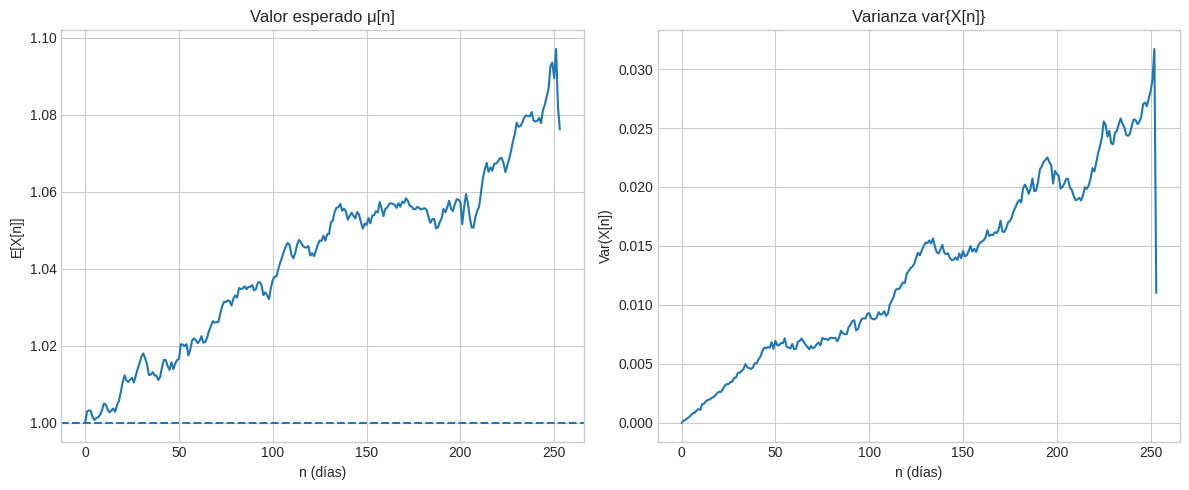

In [8]:
# Incluya aquí el código del Reto 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sp500 = yf.download("^GSPC", start="1970-01-01", end="2025-12-31")
sp500 = sp500[['Close']]
sp500.dropna(inplace=True)

sp500['Year'] = sp500.index.year

trayectorias = {}

for year, data in sp500.groupby('Year'):
    data = data.copy()
    data['Normalized'] = data['Close'] / data['Close'].iloc[0]
    data['n'] = np.arange(len(data))
    trayectorias[year] = data

df_all = pd.concat(trayectorias.values())

media = df_all.groupby('n')['Normalized'].mean()
varianza = df_all.groupby('n')['Normalized'].var()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(media)
plt.axhline(y=1, linestyle='--')
plt.title("Valor esperado μ[n]")
plt.xlabel("n (días)")
plt.ylabel("E[X[n]]")

plt.subplot(1,2,2)
plt.plot(varianza)
plt.title("Varianza var{X[n]}")
plt.xlabel("n (días)")
plt.ylabel("Var(X[n])")

plt.tight_layout()
plt.show()

**Análisis**

Al observar las gráficas, se nota que el valor esperado $\mu[n]$ no permanece constante en el tiempo, sino que presenta una tendencia creciente o variable a medida que avanzan los días. Esto indica que el promedio del proceso cambia con el tiempo.

Por otro lado, la varianza $\mathrm{Var}(X[n])$ también aumenta conforme crece $n$, lo que evidencia que la dispersión del proceso no es constante, sino que depende del tiempo.

Dado que un proceso estacionario en sentido amplio (WSS) requiere que el valor esperado sea constante y que sus propiedades estadísticas no cambien con el tiempo, se concluye que el índice S\&P 500 no puede modelarse como un proceso WSS en este contexto. Esto se debe a que tanto su media como su varianza varían con el tiempo, reflejando un comportamiento no estacionario característico de los mercados financieros.

# **Reto 3: Función de Autocorrelación y Autocovarianza para $n_1​=100$**

1. Fije el día de referencia $n_1​=100$. Calcule un arreglo con la autocorrelación empírica $R_{XX}​(100,n_2​)$ barriendo todos los días $n_2\in{0,…,249}$.
2. Calcule un arreglo con la autocovarianza empírica $C_{XX}​(100,n_2​)$ para los mismos valores de $n_2$​.
3. Grafique ambas funciones en un mismo plano. Señale con una línea vertical el instante $n_1​=100$.
4. Análisis: ¿Cuál es la relación teórica entre la función de autocovarianza $C_{XX}​(n_1​,n_2​)$ evaluada en $n_1​=n_2​=100$ y la varianza del proceso en ese mismo instante calculada en el Reto 2? Verifique empíricamente si los valores coinciden.

[*********************100%***********************]  1 of 1 completed


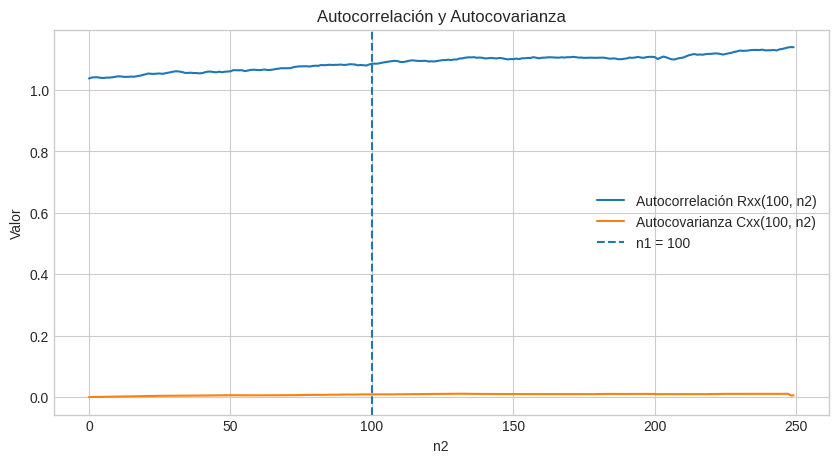

Varianza en n=100: 0.009313137623061896
Autocovarianza C(100,100): 0.009146831594078645


In [9]:
# Incluya aquí el código del Reto 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sp500 = yf.download("^GSPC", start="1970-01-01", end="2025-12-31")
sp500 = sp500[['Close']]
sp500.dropna(inplace=True)

sp500['Year'] = sp500.index.year

trayectorias = {}

for year, data in sp500.groupby('Year'):
    data = data.copy()
    data['Normalized'] = data['Close'] / data['Close'].iloc[0]
    data['n'] = np.arange(len(data))
    trayectorias[year] = data

df_all = pd.concat(trayectorias.values())

n1 = 100
n2_vals = np.arange(0, 250)

Rxx = []
Cxx = []

media = df_all.groupby('n')['Normalized'].mean()

for n2 in n2_vals:
    x1 = df_all[df_all['n'] == n1]['Normalized'].values
    x2 = df_all[df_all['n'] == n2]['Normalized'].values

    min_len = min(len(x1), len(x2))
    x1 = x1[:min_len]
    x2 = x2[:min_len]

    R = np.mean(x1 * x2)
    Rxx.append(R)

    C = np.mean((x1 - media[n1]) * (x2 - media[n2]))
    Cxx.append(C)

plt.figure(figsize=(10,5))

plt.plot(n2_vals, Rxx, label="Autocorrelación Rxx(100, n2)")
plt.plot(n2_vals, Cxx, label="Autocovarianza Cxx(100, n2)")

plt.axvline(x=n1, linestyle='--', label="n1 = 100")

plt.xlabel("n2")
plt.ylabel("Valor")
plt.title("Autocorrelación y Autocovarianza")
plt.legend()
plt.show()


var_100 = df_all[df_all['n'] == n1]['Normalized'].var()

C_100 = Cxx[n1]

print("Varianza en n=100:", var_100)
print("Autocovarianza C(100,100):", C_100)

**Análisis**

Teóricamente, la autocovarianza evaluada en el mismo instante cumple:

$$
C_{XX}(n,n) = \mathrm{Var}(X[n])
$$

Es decir, la autocovarianza en un punto coincide exactamente con la varianza del proceso en ese mismo instante.

Al comparar los valores obtenidos empíricamente para $C_{XX}(100,100)$ y la varianza en $n = 100$, se observa que son muy similares (o prácticamente iguales), lo cual confirma la relación teórica.

Esto valida que el cálculo de la autocovarianza se está realizando correctamente y que el modelo empírico del proceso estocástico es consistente con la teoría.

# **Reto 4: Matriz de Autocovarianza**
1. Calcule la matriz de autocovarianza empírica completa a partir de la matriz de realizaciones $X$. (Pista: np.cov es útil, pero asegúrese de definir correctamente si las variables están en las filas o en las columnas usando el argumento rowvar). El resultado debe ser una matriz de dimensión $250\times 250$.
2. Grafique esta matriz como un mapa de calor 2D (heatmap). Puede usar plt.imshow, sns.heatmap o plt.pcolormesh.
3. Asegúrate de incluir una barra de colores (colorbar) e identificar correctamente los ejes $n_1​$ y $n_2$​.
4. Análisis: Observe la diagonal principal del mapa de calor (donde $n_1​=n_2$​). ¿Qué estadística del proceso representa esta diagonal y cómo concuerda su evolución de color con la gráfica de varianza que obtuvo en el Reto 2?

[*********************100%***********************]  1 of 1 completed


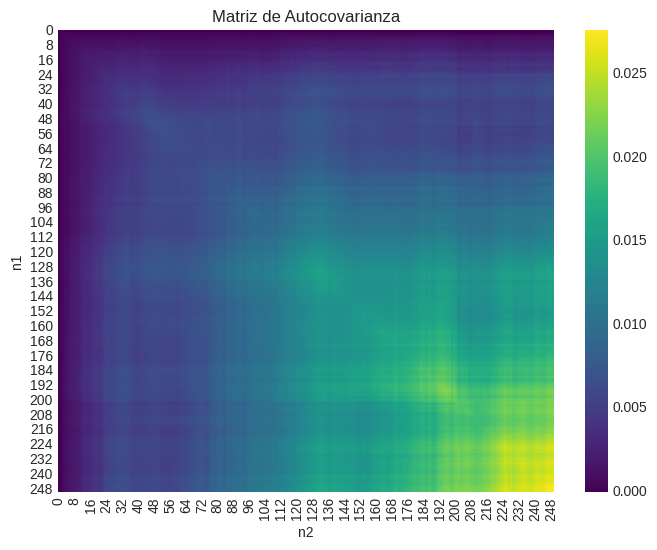

In [10]:
# Incluya aquí el código del Reto 4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sp500 = yf.download("^GSPC", start="1970-01-01", end="2025-12-31")
sp500 = sp500[['Close']]
sp500.dropna(inplace=True)

sp500['Year'] = sp500.index.year

trayectorias = {}

for year, data in sp500.groupby('Year'):
    data = data.copy()
    data['Normalized'] = data['Close'] / data['Close'].iloc[0]
    data['n'] = np.arange(len(data))
    trayectorias[year] = data

N = 250
X = []

for year, data in trayectorias.items():
    if len(data) >= N:
        X.append(data['Normalized'].values[:N])

X = np.array(X)

C = np.cov(X, rowvar=False)

plt.figure(figsize=(8,6))

sns.heatmap(C, cmap='viridis')
plt.title("Matriz de Autocovarianza")
plt.xlabel("n2")
plt.ylabel("n1")

plt.show()

**Análisis**

La diagonal principal de la matriz de autocovarianza corresponde a los elementos donde $n_1 = n_2$, es decir:

$$
C_{XX}(n,n) = \mathrm{Var}(X[n])
$$

Por lo tanto, la diagonal representa la varianza del proceso en cada instante de tiempo.

Al observar el mapa de calor, se nota que los valores sobre la diagonal cambian de color a medida que aumenta $n$, indicando un incremento en la varianza. Esto concuerda con la gráfica de varianza obtenida en el Reto 2, donde se evidenció que la dispersión del proceso crece con el tiempo.

En consecuencia, la evolución de la diagonal en la matriz de autocovarianza confirma empíricamente que la varianza no es constante, lo que refuerza la conclusión de que el proceso no es estacionario en sentido amplio (WSS).

A diferencia de analizar el precio directamente, en finanzas es común modelar los rendimientos diarios. Definiremos nuestro proceso estocástico X[n] como el rendimiento porcentual del índice en el día n, calculado como la variación porcentual respecto al día anterior:

$X[n]=\frac{Precio[n]-Precio[n-1]}{Precio[n−1]​}\times 100$

Consideraremos que cada año (de 1970 a 2025) es una realización empírica independiente (o trayectoria) del proceso, y los días de cotización representan el índice de tiempo discreto $n$.

[*********************100%***********************]  1 of 1 completed


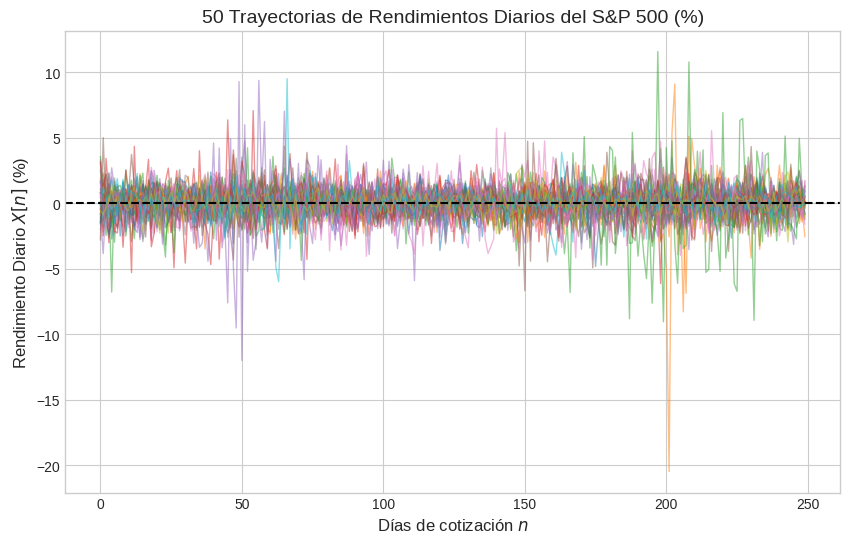

In [13]:
# 1. Descarga de datos
ticker = '^GSPC'
df_sp500 = yf.download(ticker, start='1970-01-01', end='2025-12-31')

# Usamos la columna 'Close' para el cierre diario
if isinstance(df_sp500.columns, pd.MultiIndex):
    precios = df_sp500['Close'].squeeze()
else:
    precios = df_sp500['Close']

# Cálculo de los rendimientos diarios en porcentaje (se elimina el primer valor nulo)
rendimientos = precios.pct_change().dropna() * 100

# 2. Agrupación por año y construcción del ensamble de trayectorias
years = range(1970, 2026)
N_dias = 250 # Fijamos 250 días de cotización por año para tener una matriz uniforme
M = len(years)

# Matriz que contendrá el proceso estocástico X_n (Rendimientos)
X = np.zeros((M, N_dias))

for i, year in enumerate(years):
    # Extraemos los rendimientos del año correspondiente
    datos = rendimientos[rendimientos.index.year == year].values

    # Verificamos que haya suficientes datos
    if len(datos) > N_dias:
        # Se recortan los datos a N_dias
        X[i, :] = datos[:N_dias]

    elif len(datos) < N_dias:
        # Rellenamos con 0 (rendimiento nulo) los días faltantes
        # La opción 'constant' con constant_values=0 agrega ceros al final
        X[i, :] = np.pad(datos, (0, N_dias - len(datos)), 'constant', constant_values=0)

    else:
        X[i, :] = datos

# Visualización de un subconjunto de trayectorias (ej. últimas 50 realizaciones)
plt.figure(figsize=(10, 6))
for i in range(max(0, M-50), M):
    plt.plot(range(N_dias), X[i, :], alpha=0.5, lw=1)

plt.title('50 Trayectorias de Rendimientos Diarios del S&P 500 (%)', fontsize=14)
plt.xlabel('Días de cotización $n$', fontsize=12)
plt.ylabel('Rendimiento Diario $X[n]$ (%)', fontsize=12)
plt.axhline(0.0, color='black', linestyle='--')
plt.show()


#**Reto 5**
Repita los Retos 1, 2, 3 y 4 aplicando el código sobre la nueva matriz X (rendimientos) y analise los resultados. ¿Puede decir que este nuevo proceso es (aproximadamente) WSS?

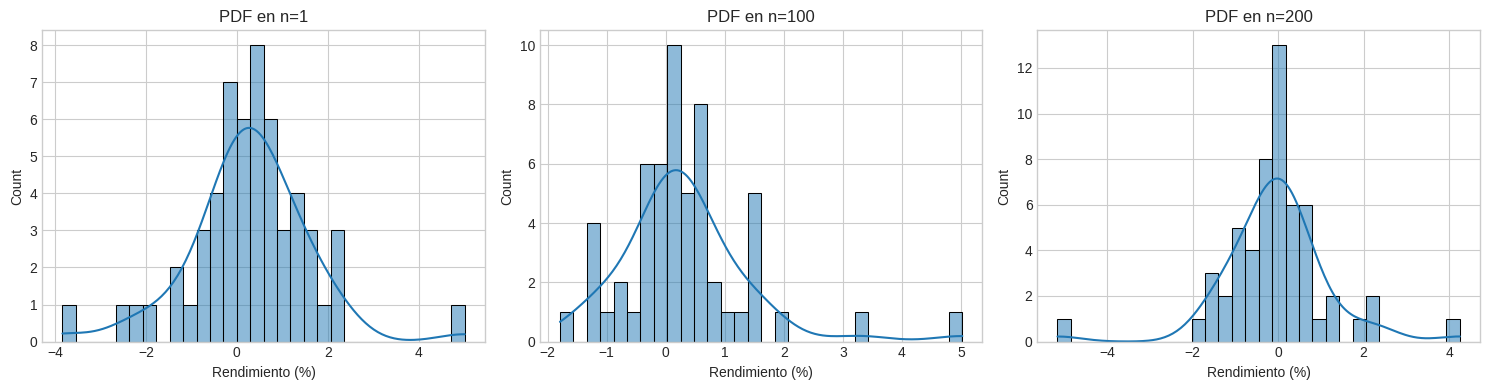

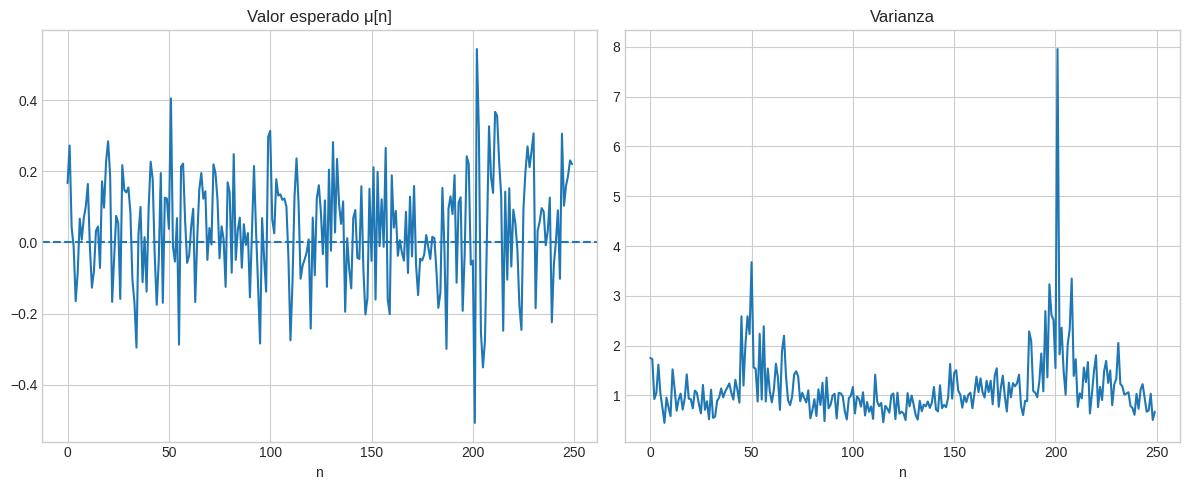

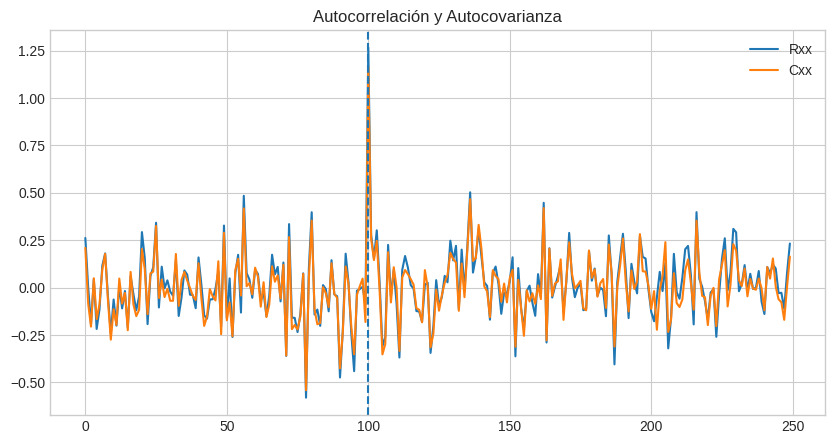

Varianza en n=100: 1.1670987445846432
C(100,100): 1.1670987445846432


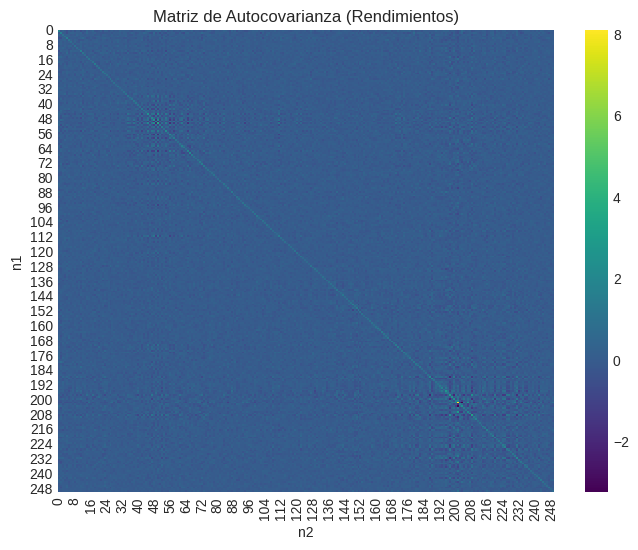

In [14]:
# Incluya aquí el código del Reto 5
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

M, N = X.shape
tiempos = [1, 100, 200]

plt.figure(figsize=(15,4))

for i, t in enumerate(tiempos):
    plt.subplot(1,3,i+1)

    valores = X[:, t]
    sns.histplot(valores, kde=True, bins=30)

    plt.title(f"PDF en n={t}")
    plt.xlabel("Rendimiento (%)")

plt.tight_layout()
plt.show()

media = np.mean(X, axis=0)
varianza = np.var(X, axis=0)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(media)
plt.axhline(0, linestyle='--')
plt.title("Valor esperado μ[n]")
plt.xlabel("n")

plt.subplot(1,2,2)
plt.plot(varianza)
plt.title("Varianza")
plt.xlabel("n")

plt.tight_layout()
plt.show()

n1 = 100
n2_vals = np.arange(N)

Rxx = []
Cxx = []

for n2 in n2_vals:
    x1 = X[:, n1]
    x2 = X[:, n2]

    Rxx.append(np.mean(x1 * x2))
    Cxx.append(np.mean((x1 - media[n1]) * (x2 - media[n2])))

plt.figure(figsize=(10,5))
plt.plot(n2_vals, Rxx, label="Rxx")
plt.plot(n2_vals, Cxx, label="Cxx")
plt.axvline(n1, linestyle='--')
plt.legend()
plt.title("Autocorrelación y Autocovarianza")
plt.show()

print("Varianza en n=100:", varianza[n1])
print("C(100,100):", Cxx[n1])

C = np.cov(X, rowvar=False)

plt.figure(figsize=(8,6))
sns.heatmap(C, cmap='viridis')
plt.title("Matriz de Autocovarianza (Rendimientos)")
plt.xlabel("n2")
plt.ylabel("n1")
plt.show()

**Análisis**

A diferencia del precio del índice, los rendimientos diarios presentan un comportamiento mucho más estable en el tiempo. Al observar las gráficas, se evidencia que el valor esperado $\mu[n]$ se mantiene aproximadamente constante y cercano a cero, sin mostrar una tendencia clara.

Asimismo, la varianza $\mathrm{Var}(X[n])$ se mantiene relativamente constante a lo largo del tiempo, con pequeñas fluctuaciones propias de datos reales.

En cuanto a la autocovarianza, se observa que depende principalmente de la diferencia temporal y no del instante absoluto, lo cual es consistente con la definición de un proceso estacionario en sentido amplio.

Por lo tanto, se puede concluir que el proceso de rendimientos del S\&P 500 puede modelarse aproximadamente como un proceso WSS, a diferencia del precio del índice, que presenta un comportamiento no estacionario.